In [1]:
# RFM Customer Segmentation Analysis

# This project analyzes customer behavior using RFM (Recency, Frequency, Monetary) methodology.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #görselleştirme
import seaborn as sns  #görselleştirme

sns.set_theme(style='whitegrid')
print('Kütüphaneler yüklendi ✅')


Kütüphaneler yüklendi ✅


In [3]:
df = pd.read_csv(r"C:\Users\2023\OneDrive\Masaüstü\Sample - Superstore.csv", encoding='latin1') #df=dataframe (tablo) csv dosyasını alıp python a getirdi
df['Order Date'] = pd.to_datetime(df['Order Date']) #Tarih sütununu Python'ın anlayacağı formata çevirelim
print(f'Toplam kayıt sayısı: {len(df)}')
print(f'Benzersiz Müşteri Sayısı: {df["Customer ID"].nunique()}')
df.head()

Toplam kayıt sayısı: 9994
Benzersiz Müşteri Sayısı: 793


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
analysis_date = df['Order Date'].max() + pd.Timedelta(days=1) # Analiz tarihi: veri setindeki en son siparişten 1 gün sonrası
print(f'Referans Tarihi: {analysis_date.date()}')

print("-------RFM HESAPLAMA---------")
rfm=df.groupby('Customer ID').agg(
    CustomerName=('Customer Name', 'first'),
    Recency     =('Order Date', lambda x: (analysis_date- x.max()).days), # son alışveristen bu yana kaç gün geçmiş?
    Frequency   =('Order ID', 'nunique'),  #kaç farklı sipariş?
    Monetary    = ('Sales','sum') #Toplam harcama($)
).reset_index()

print('\nRFM Tablosu(İlk 5 satır):')
rfm.head()
    

Referans Tarihi: 2017-12-31
-------RFM HESAPLAMA---------

RFM Tablosu(İlk 5 satır):


,Customer ID,CustomerName,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.560
1,AA-10375,Allen Armold,20,9,1056.390
2,AA-10480,Andrew Allen,260,4,1790.512
3,AA-10645,Anna Andreadi,56,6,5086.935
4,AB-10015,Aaron Bergman,416,3,886.156


In [5]:
print('📊 RFM İstatistikleri:') 
rfm[['Recency','Frequency','Monetary']].describe().round(2) # Temel istatistikleri verir 

📊 RFM İstatistikleri:


,Recency,Frequency,Monetary
count,793.00,793.00,793.00
mean,147.80,6.32,2896.85
std,186.21,2.55,2628.67
min,1.00,1.00,4.83
25%,31.00,5.00,1146.05
50%,76.00,6.00,2256.39
75%,184.00,8.00,3785.28
max,1166.00,17.00,25043.05


In [6]:
#qcut ile müşterileri 4 eşit gruba böleceğiz.
rfm['R_Score']= pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1]) #Recency ters mantık ile skorlanır (az gün => iyi = 4 )
rfm['F_Score']= pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

#Toplan RFM Skoru
rfm['RFM_Score']=rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# RFM string (segment etiketi için)
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print('RFM Skorları Eklendi:')
rfm[['CustomerName', 'Recency', 'Frequency','Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10)

RFM Skorları Eklendi:


,CustomerName,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,Alex Avila,185,5,5563.560,1,1,4,6
1,Allen Armold,20,9,1056.390,4,4,1,9
2,Andrew Allen,260,4,1790.512,1,1,2,4
3,Anna Andreadi,56,6,5086.935,3,2,4,9
4,Aaron Bergman,416,3,886.156,1,1,1,3
5,Adam Bellavance,55,8,7755.620,3,3,4,10
6,Adrian Barton,42,10,14473.571,3,4,4,11
7,Aimee Bixby,42,5,966.710,3,1,1,5
8,Alan Barnes,26,8,1113.838,4,3,1,8
9,Alejandro Ballentine,167,9,914.532,2,4,1,7


In [7]:
def assign_segment(row):  #Müşterileri tek tek alıp hangi segmente ait olduğu bulmak için fonk. oluşturuyoruz
    score = row['RFM_Score']
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if score >= 11:  # En düşük RFM skoru 3, en yüksek ise 12 olabilir.
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'New Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif r <= 2 and score >= 6:
        return 'At Risk'
    elif r == 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1) #Fonksiyonu tabloya uygulama

In [8]:
# Segment dağılımı
segment_counts = rfm['Segment'].value_counts() #Segmentte kaç müşteri var?
print("Segment Dağılımı:")
print(segment_counts)
import matplotlib.pyplot as plt

Segment Dağılımı:
Segment
Loyal Customers        214
New Customers          129
Lost Customers         124
Potential Loyalists    121
Champions              100
At Risk                 56
Others                  49
Name: count, dtype: int64


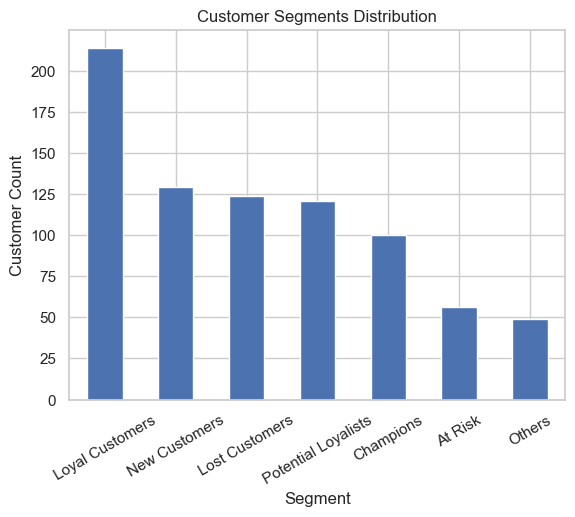

In [9]:
# GRAFİK 1: Segment Dağılımı (Bar chart)
segment_counts = rfm['Segment'].value_counts()

segment_counts.plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=30)
plt.show()

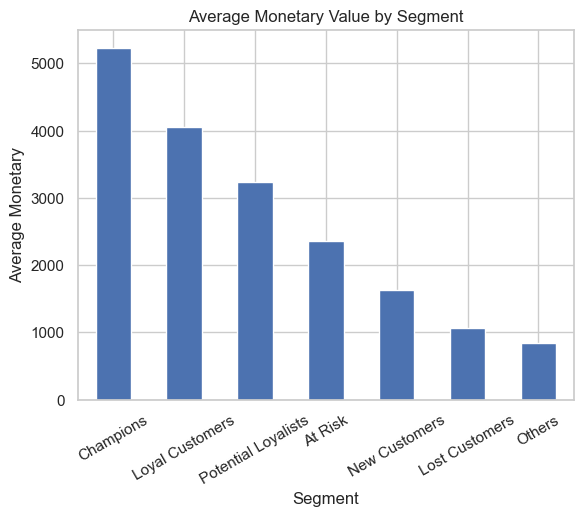

In [10]:
# GRAFİK 2: Segment Bazlı Monetary Ortalaması (Bar chart)
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Monetary Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Monetary")
plt.xticks(rotation=30)
plt.show()

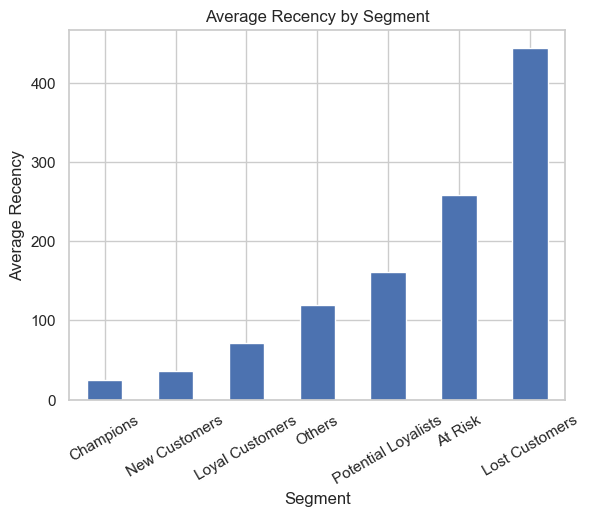

,Recency,Frequency,Monetary
Segment,,,
At Risk,258.27,5.48,2361.35
Champions,24.74,9.51,5235.90
Lost Customers,444.24,3.70,1066.58
Loyal Customers,71.09,7.98,4052.12
New Customers,36.16,4.26,1627.05
Others,118.82,4.10,834.89
Potential Loyalists,161.02,6.89,3232.78


In [11]:
# GRAFİK 3: Segment bazlı Recency / Frequency / Monetary (Tablo veya Grafik)
#Average Recency (Days)
rfm.groupby('Segment')['Recency'].mean().sort_values().plot(kind='bar')
plt.title("Average Recency by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Recency")
plt.xticks(rotation=30)
plt.show()

rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

In [12]:
# Şampiyonları listele
print('🏆 Şampiyonlar (Top 10):')
champions = rfm[rfm['Segment'] == 'Champions']\
                .sort_values('Monetary', ascending=False)

champions.head(10)

🏆 Şampiyonlar (Top 10):


,Customer ID,CustomerName,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment
6,AB-10105,Adrian Barton,42,10,14473.5710,3,4,4,11,344,Champions
434,KL-16645,Ken Lonsdale,48,12,14175.2290,3,4,4,11,344,Champions
683,SE-20110,Sanjit Engle,10,11,12209.4380,4,4,4,12,444,Champions
311,GT-14710,Greg Tran,37,11,11820.1200,3,4,4,11,344,Champions
497,ME-17320,Maria Etezadi,43,10,10663.7280,3,4,4,11,344,Champions
387,JL-15835,John Lee,22,11,9799.9230,4,4,4,12,444,Champions
355,JE-15715,Joe Elijah,47,10,8697.8430,3,4,4,11,344,Champions
597,PK-19075,Pete Kriz,10,12,8646.9340,4,4,4,12,444,Champions
556,NC-18535,Nick Crebassa,7,7,8241.7390,4,3,4,11,434,Champions
328,HM-14860,Harry Marie,3,10,8236.7648,4,4,4,12,444,Champions


In [13]:
# Risk altındaki müşterileri listele
at_risk = rfm[rfm['Segment'] == 'At Risk']\
            .sort_values('Monetary', ascending=False)

at_risk .head(10)

,Customer ID,CustomerName,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment
90,BM-11140,Becky Martin,308,4,11789.6300,1,1,4,6,114,At Risk
588,PF-19120,Peter Fuller,836,4,9062.8640,1,1,4,6,114,At Risk
0,AA-10315,Alex Avila,185,5,5563.5600,1,1,4,6,114,At Risk
163,CM-12715,Craig Molinari,1036,4,3984.4524,1,1,4,6,114,At Risk
768,TS-21655,Trudy Schmidt,239,5,3368.0940,1,2,3,6,123,At Risk
667,SC-20020,Sam Craven,782,5,3362.9636,1,2,3,6,123,At Risk
507,MG-18145,Mike Gockenbach,85,4,3061.5430,2,1,3,6,213,At Risk
747,TG-21310,Toby Gnade,338,5,3058.3720,1,2,3,6,123,At Risk
189,DB-12970,Darren Budd,242,5,2839.2272,1,2,3,6,123,At Risk
182,CV-12295,Christina VanderZanden,255,5,2830.6280,1,2,3,6,123,At Risk
